# Description
This script compares cest values of regions within network vs between network.


## Import Packages

In [8]:
import os
import glob
import numpy as np
import pandas as pd
#import network_fcon as fc
import scipy as sp
from scipy.stats import pearsonr
from scipy.stats import linregress
import seaborn as sns
import matplotlib.pyplot as plt
import re
import seaborn as sns
import statsmodels.formula.api as smf
from netneurotools import datasets, plotting
import nibabel as nib
from netneurotools.datasets import fetch_cammoun2012
from nilearn import plotting
from nilearn.image import load_img
from matplotlib.colors import ListedColormap

### Set Variables and Paths

In [35]:
# Set Variables
dataset = 'longglucest_outputmeasures2'
atlas = 'atl-Cammoun2012_res-500' #'Schaefer2018_1000Parcels_17Networks'
parcels = pd.read_csv('/Users/pecsok/Library/CloudStorage/Box-Box/GluCEST PhD/Manuscripts/Neuromaps/Data/parcels_new.csv')
figpath = '/Users/pecsok/Library/CloudStorage/Box-Box/GluCEST PhD/Manuscripts/Neuromaps/Results'


inv2_nifti =  '/Users/pecsok/Desktop/125511_10906/125511_10906-INV2.nii'
cest_nifti =  '/Users/pecsok/Desktop/125511_10906/125511_10906-cest.nii'

#uni_nifti =  '/Users/pecsok/Desktop/20011_10888/20011_10888-UNI.nii'
#cest_nifti =  '/Users/pecsok/Desktop/20011_10888/20011_10888-cest.nii'



### Create map with all von economo parcels represented in dataset

In [29]:
"""
# Add numeric column to info based von_economo label
von_economo_map = {label: idx for idx, label in enumerate(info['von_economo'].unique(), start=1)}
info['von_economo_numeric'] = info['von_economo'].map(von_economo_map)
info.loc[~info['label'].isin(parcels['Parcel'].tolist()), 'von_economo_numeric'] = 0

print(info['von_economo_numeric'])
print(info['von_economo_numeric'].unique())


# Load in nifti and data
nifti_file = cam['scale500']
nifti_img = nib.load(nifti_file)
nifti_data = nifti_img.get_fdata()
filled_data = np.zeros_like(nifti_data)
 
for _, row in info.iterrows():
    region_id = row['id']
    #print(region_id)
    von_economo_value = row['von_economo_numeric']
    
    # Replace region_id in the NIfTI with von_economo_value
    filled_data[nifti_data == region_id] = von_economo_value

# Create new nifti
new_nifti_img = nib.Nifti1Image(filled_data, affine=nifti_img.affine, header=nifti_img.header)
output_file = os.path.join(figpath,"von_economo_new.nii.gz")
nib.save(new_nifti_img, output_file)
"""

NameError: name 'info' is not defined

### Make Von Economo maps for each region

In [24]:
"""
for von_ec in vonecon_regions:
    filled_data = np.zeros_like(nifti_data)
    for _, row in info.iterrows():
        region_id = row['id']
        i = von_economo_map.get(von_ec, None)
        if row['von_economo_numeric'] == i:
            von_economo_value = row['von_economo_numeric']
            # Replace region_id in the NIfTI with von_economo_value
            filled_data[nifti_data == region_id] = von_economo_value
            pass
    # Create new nifti
    region_name = vonecon_names[von_ec]
    new_nifti_img = nib.Nifti1Image(filled_data, affine=nifti_img.affine, header=nifti_img.header)
    output_file = os.path.join(figpath,"von_economo_" + region_name +".nii.gz")
    nib.save(new_nifti_img, output_file)
"""

NameError: name 'vonecon_regions' is not defined

### Plot 

(192, 264, 304)
(192, 264, 304)
(1, 224, 224, 22)
(192, 264, 304)


/Users/pecsok/.local/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:308: UserWarning: empty mask
  ims = self._map_show(img, type="imshow", threshold=threshold, **kwargs)
/Users/pecsok/.local/lib/python3.11/site-packages/numpy/ma/core.py:2820: UserWarning: Warning: converting a masked element to nan.
  _data = np.array(data, dtype=dtype, copy=copy,


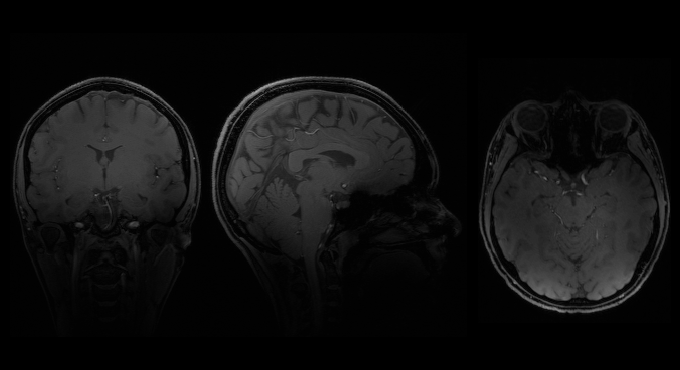

In [40]:
from nilearn.image import index_img
from nilearn.image import math_img
from nilearn.image import resample_to_img


#uni_img = load_img(uni_nifti)
inv2_img = load_img(inv2_nifti)
cest_img = load_img(cest_nifti)
cest_img_3d = index_img(cest_img, 1)
cest_img_clipped = math_img("np.clip(img, 0, 20)", img=cest_img_3d)
cest_img_resampled = resample_to_img(cest_img_clipped, inv2_img, interpolation='nearest')


#print(np.min(cest_img_normalized.get_fdata()), np.max(cest_img_normalized.get_fdata()))

print(uni_img.shape)
print(inv2_img.shape)
print(cest_img.shape)
print(cest_img_resampled.shape)

# Plotting:
# Set color scheme
#Something where hot colors = higher value, cooler colors = lower?

cest_display = plotting.plot_roi(
    cest_img_clipped,
    bg_img=inv2_img,
    #title="Mask Overlay",
    display_mode="ortho",
    #cut_coords=[2], #(2, 0, 0),
    cmap="viridis",
    draw_cross=False,
    annotate = False
)
cest_display.title = None  # Remove the title managed by nilearn
plt.gcf()  #.suptitle("Mask Overlay", fontsize=16)  # Add a clean custom title

plotting.show()



In [4]:
### Make CEST histogram

/var/folders/kk/w6xmtt2d55xfbxvb6wcqhq580000gp/T/ipykernel_28857/888517794.py:14: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8, 5))


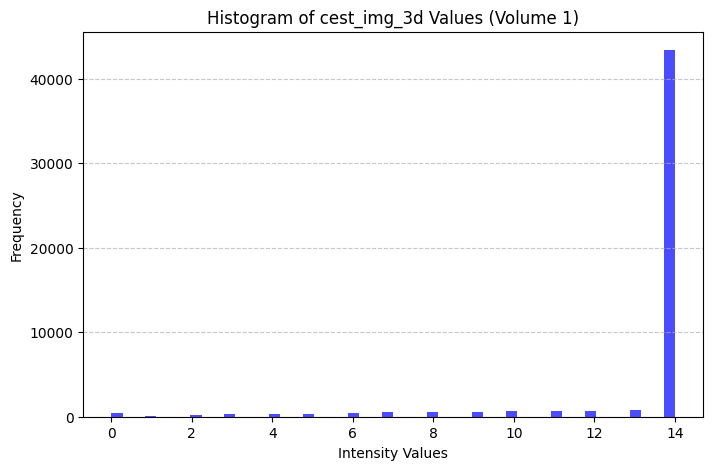

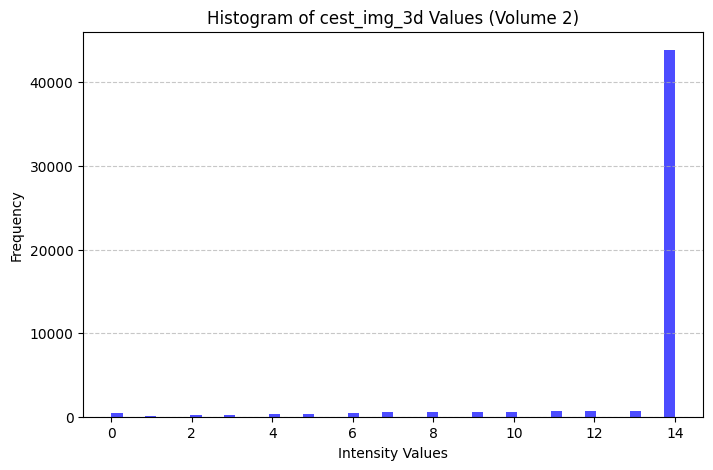

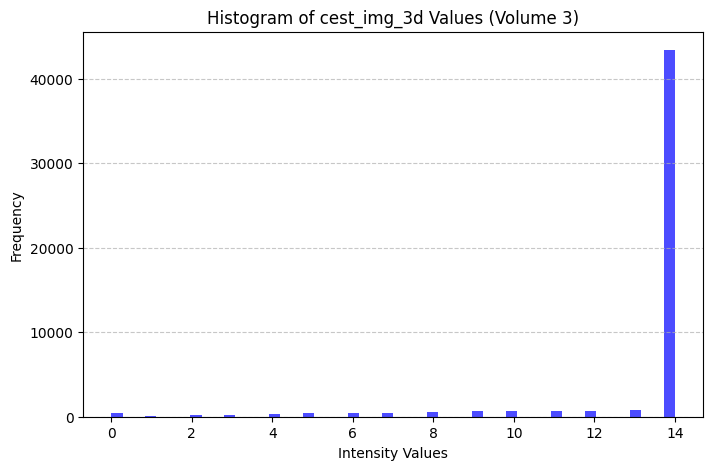

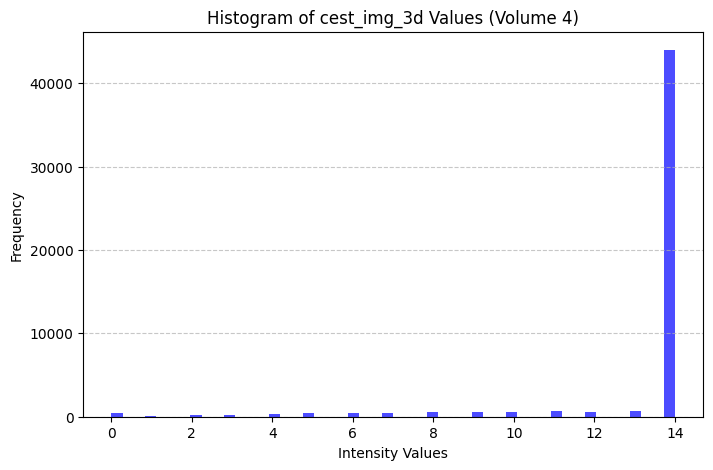

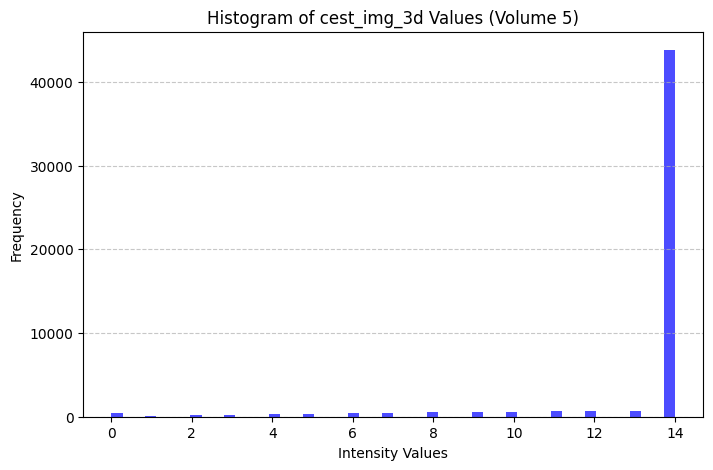

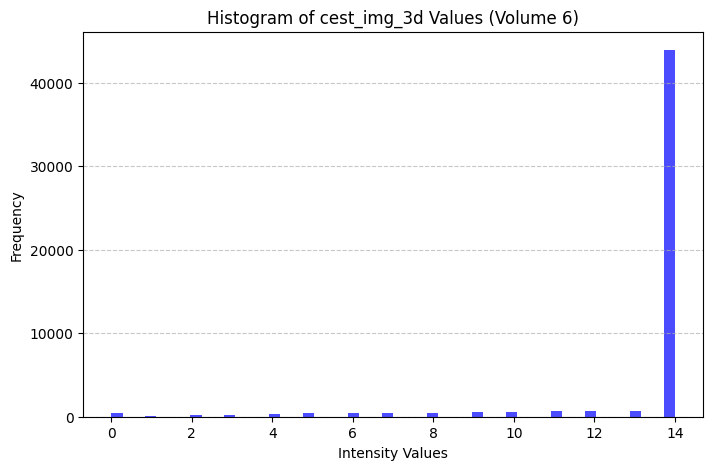

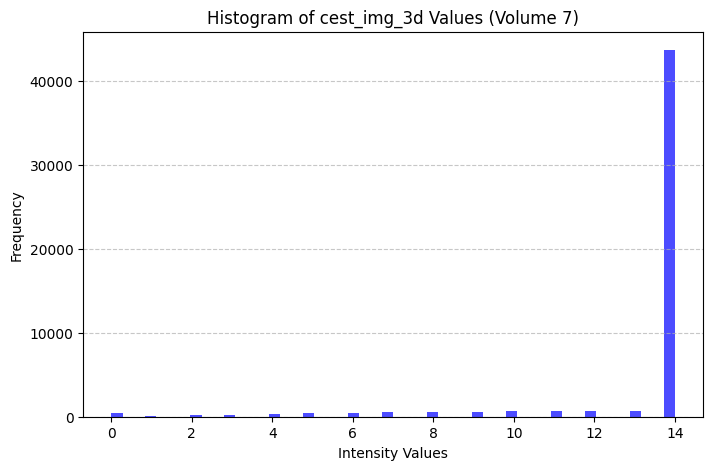

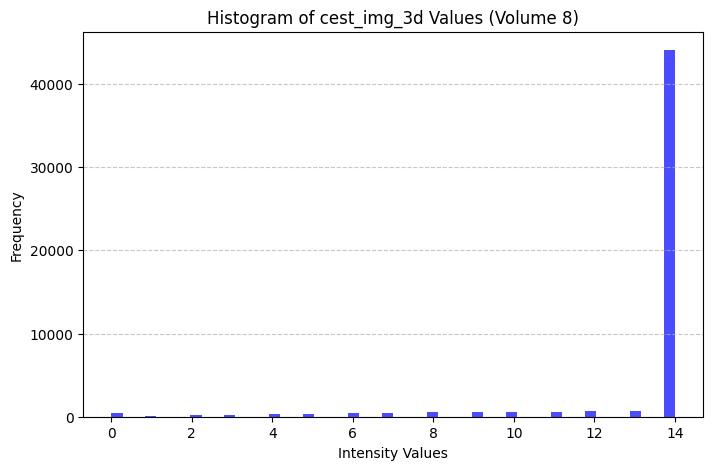

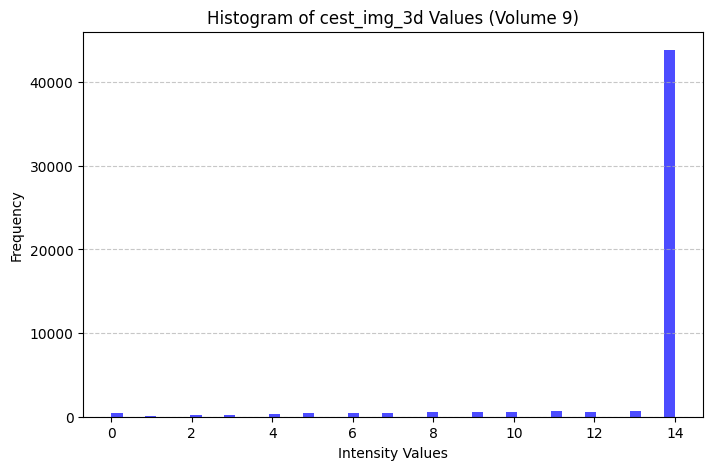

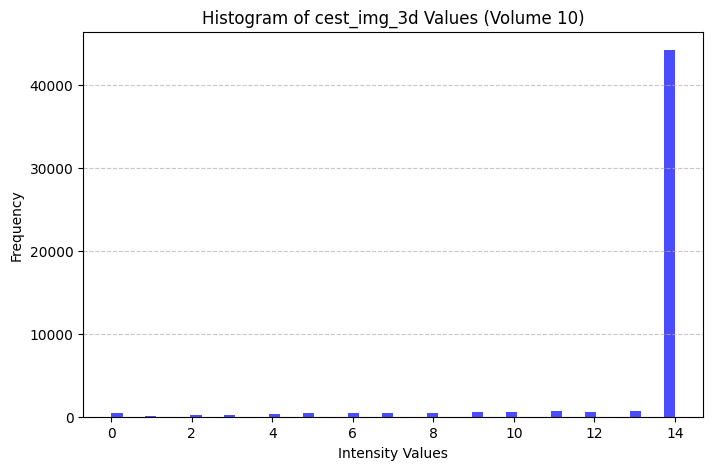

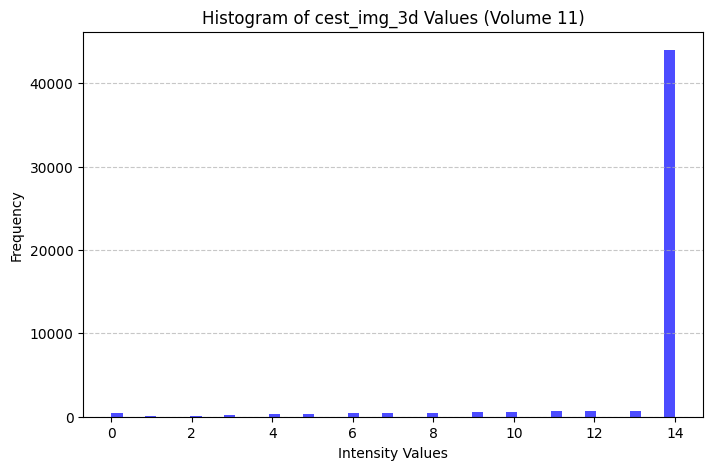

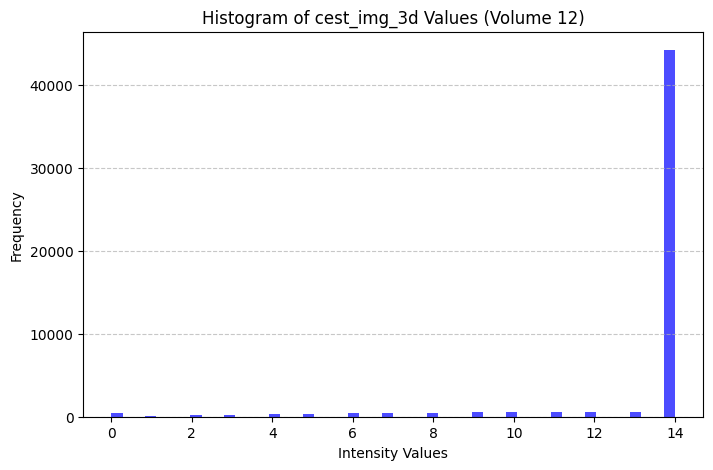

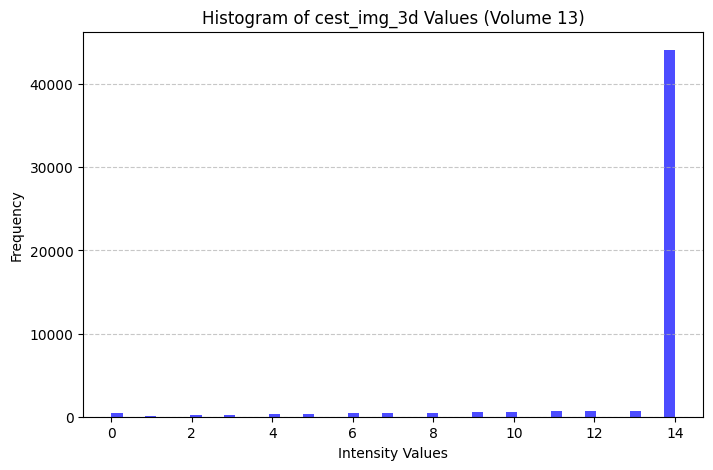

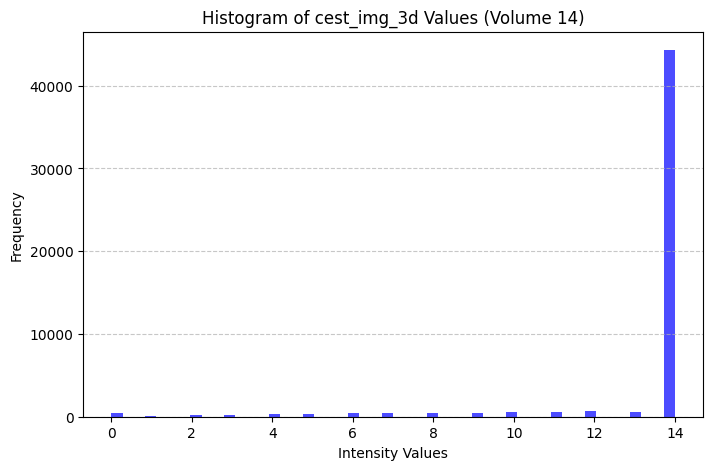

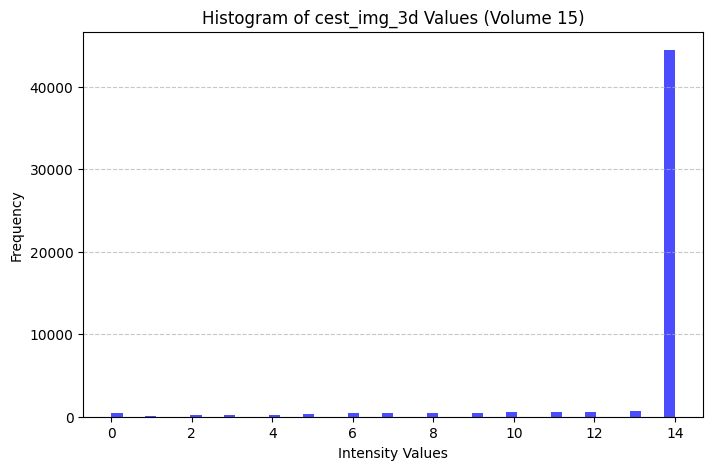

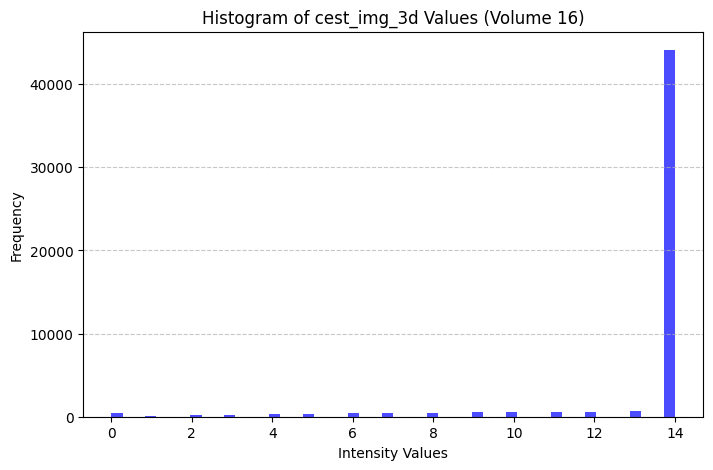

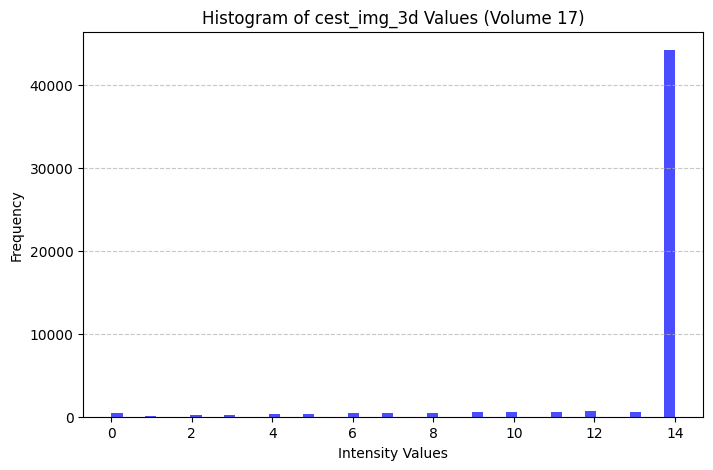

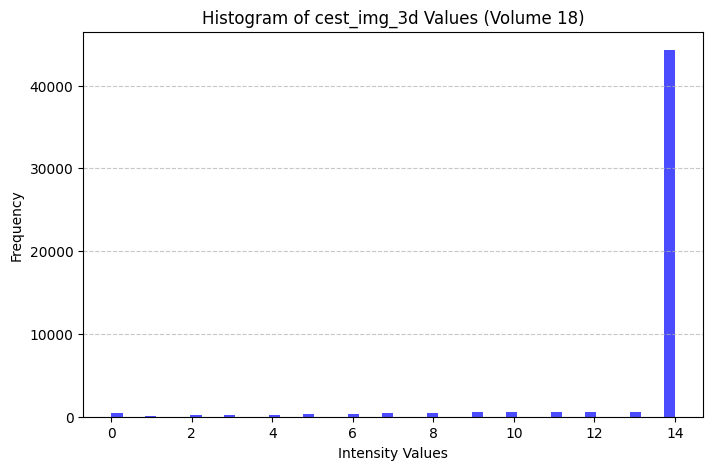

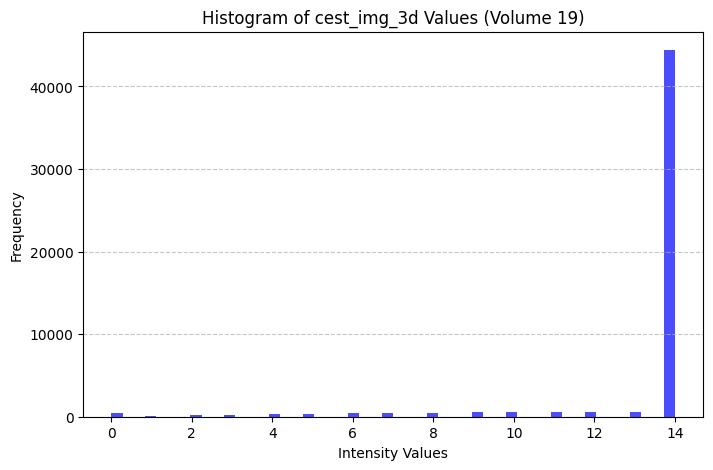

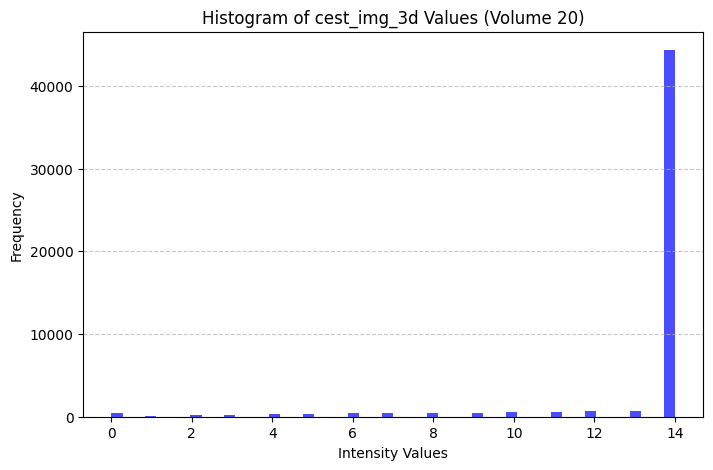

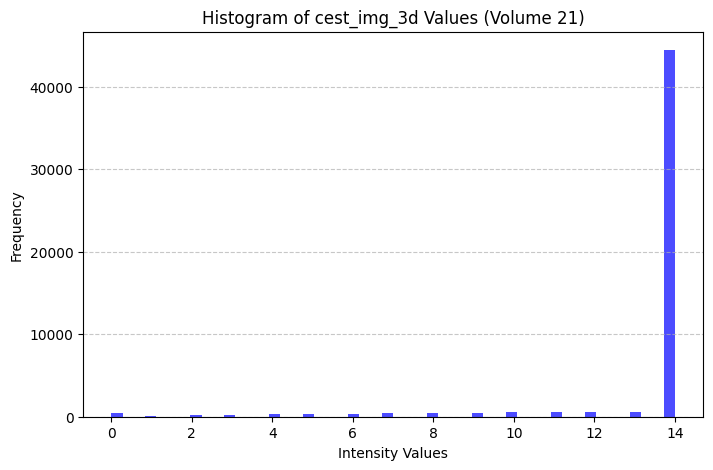

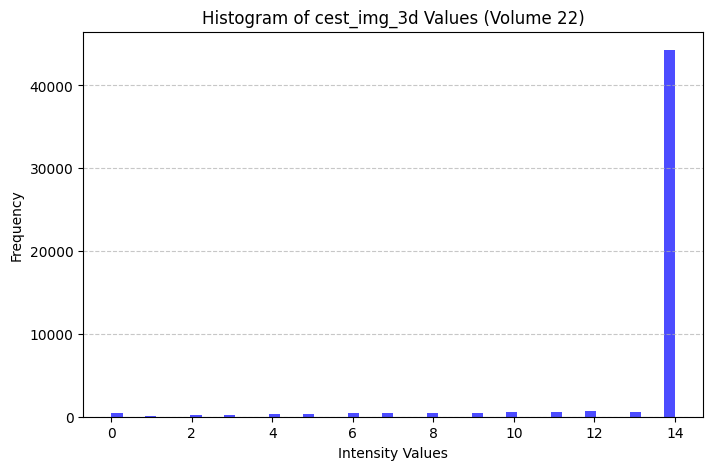

In [30]:
cest_img = load_img(cest_nifti)

n_volumes = cest_img.shape[3] # Number of volumes in the 4th dimension

for i in range(n_volumes):
    cest_img_3d = index_img(cest_img, i)  # Extract the ith 3D image
    cest_img_clipped = math_img("np.clip(img, 0, 14)", img=cest_img_3d)
    cest_data = cest_img_clipped.get_fdata()
    
    # Flatten the data to 1D for the histogram
    cest_flattened = cest_data.flatten()
    
    # Plot the histogram
    plt.figure(figsize=(8, 5))
    plt.hist(cest_flattened, bins=50, color='blue', alpha=0.7)
    plt.title(f"Histogram of cest_img_3d Values (Volume {i+1})")
    plt.xlabel("Intensity Values")
    plt.ylabel("Frequency")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    #plt.show()

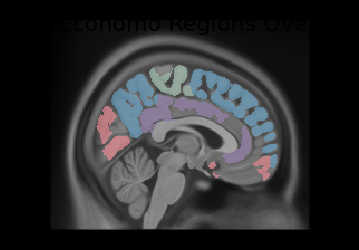

In [90]:
# Initialize a combined mask for all regions
combined_filled_data = np.zeros_like(nifti_data)

# Create a color map for all regions
all_colors = [vonecon_palette[region] for region in vonecon_regions]
custom_cmap = ListedColormap(all_colors)

# Loop through each Von Economo region
for von_ec in vonecon_regions:
    for _, row in info.iterrows():
        region_id = row['id']
        i = von_economo_map.get(von_ec, None)
        if row['von_economo_numeric'] == i:
            von_economo_value = vonecon_regions.index(von_ec) + 1  # Assign a unique index to each region
            combined_filled_data[nifti_data == region_id] = von_economo_value

# Create a combined NIfTI image for all regions
combined_nifti_img = nib.Nifti1Image(combined_filled_data, affine=nifti_img.affine, header=nifti_img.header)

# Save the combined NIfTI image
output_file = os.path.join(figpath, "von_economo_combined.nii.gz")
nib.save(combined_nifti_img, output_file)

# Plot the combined image
roi_display = plotting.plot_roi(
    combined_nifti_img,
    bg_img=mni_img,
    display_mode="x",
    cut_coords=[2], #(2, 0, 0),
    cmap=custom_cmap,
    draw_cross=False,
    annotate = False
)

# Add a title
plt.gcf().suptitle("Von Economo Regions Overlay", fontsize=16)

# Show the plot
plotting.show()

In [ ]:
from nilearn.image import index_img
from nilearn.image import math_img

inv2_img = load_img(inv2_nifti)
cest_img = load_img(cest_nifti)
cest_img_3d = index_img(cest_img, 0)

print(inv2_img.shape)
print(cest_img.shape)
print(cest_img_3d.shape)

# Plotting:

cest_display = plotting.plot_roi(
    cest_img_clipped,
    bg_img=uni_img,
    #title="Mask Overlay",
    display_mode="ortho",
    #cut_coords=[2], #(2, 0, 0),
    cmap="viridis",
    draw_cross=False,
    annotate = False
)
cest_display.title = None  # Remove the title managed by nilearn
plt.gcf().suptitle("Mask Overlay", fontsize=16)  # Add a clean custom title